In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../0-Dataset/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

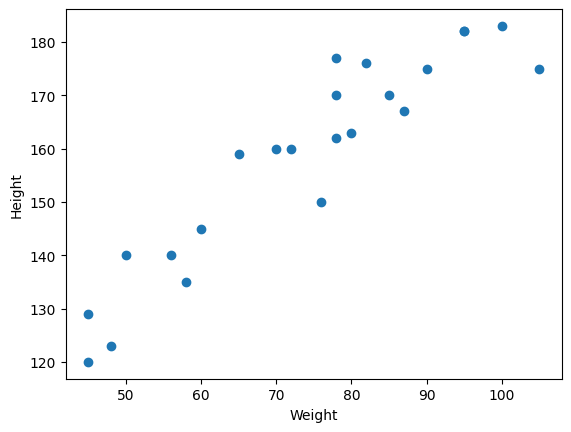

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel("Height")

In [11]:
from sklearn.model_selection import train_test_split
X = df[['Weight']]
y = df['Height']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23, 1), (18, 1), (5, 1), (18,), (5,))

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [17]:
lr.coef_

array([17.03440872])

In [18]:
lr.intercept_

157.5

In [19]:
y_pred = lr.predict(X_test)

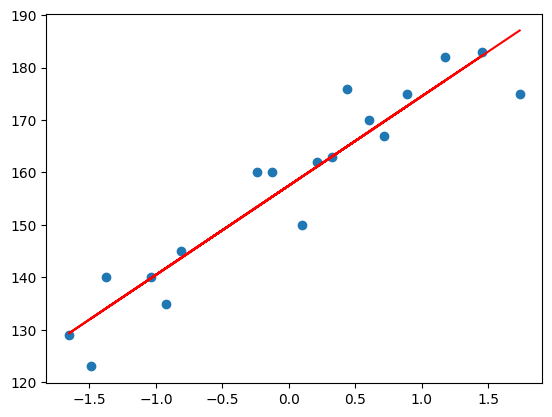

In [23]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), 'r-')
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(score)

9.822657814519232
109.77592599051664
0.776986986042344


In [29]:
## new data points

scaled_weight = sc.transform([[80]])
scaled_weight[0]

array([0.32350772])

In [30]:
print('The height prediciton for weight 80kg is: ', lr.predict([scaled_weight[0]]))

The height prediciton for weight 80kg is:  [163.01076266]


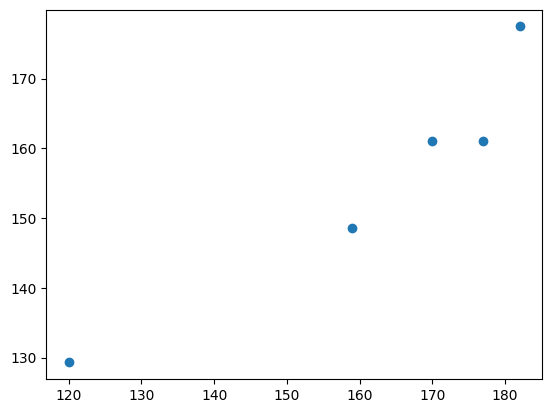

In [31]:
plt.scatter(y_test, y_pred)

In [32]:
residuals = y_test-y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

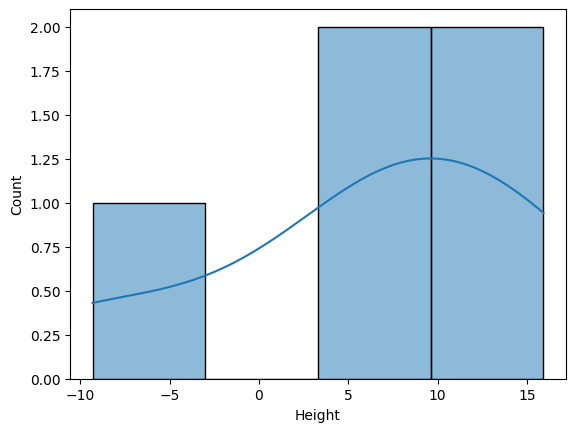

In [34]:
sns.histplot(residuals, kde=True)

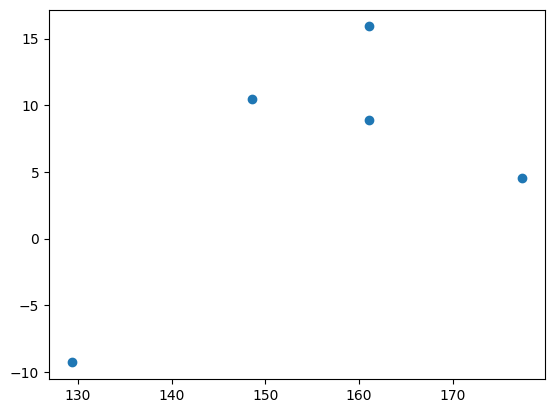

In [35]:
plt.scatter(y_pred, residuals)

#### If you got the plot of y predicted and residual values are normally distributed then you can say that your model is good model